## Quasar classification
In this excercise, using deep learning techniques, we want to classify Quasars based on their color measurments .   

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
path = 'solutions/galaxyquasar.csv'
from astropy.table import Table
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc
from sklearn import metrics 
from sklearn.metrics import accuracy_score
import sklearn.model_selection
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score
from itertools import product
from sklearn.model_selection import StratifiedKFold
import os

Loading the data and visualizing it:

In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
data = Table.read(path)
print(data)

   u        g        r        i        z     class      z1         zerr    
-------- -------- -------- -------- -------- ------ ---------- ------------
18.97213 18.53676  18.5828 18.34936 18.29215    QSO  0.5228189 0.0001547483
19.24592 17.47646 16.47817 16.04472 15.68851 GALAXY  0.1228459 2.816076e-05
19.43536 17.70268 16.91565 16.58327 16.39128 GALAXY        0.0          0.0
19.31626 18.18312 17.39591 16.94549 16.65395 GALAXY  0.1474355 9.310701e-06
19.28828 19.11188 18.88937 18.80013 18.49183    QSO   2.011455 0.0006307968
17.60994 15.90911  15.0209 14.54955 14.19971 GALAXY 0.04619161 1.022329e-05
18.50014 17.42286 17.03657 16.76236 16.63258 GALAXY  0.0516851 6.667251e-06
19.53253 19.49823 19.42254 19.07912 18.90426    QSO    1.88844 0.0005242734
19.37014 17.94086   17.154 16.74367 16.42825 GALAXY   0.137445 1.284492e-05
18.94777 16.99748 16.10991 15.71294 15.38205 GALAXY 0.05139576 1.215115e-05
     ...      ...      ...      ...      ...    ...        ...          ...
19.33615 18.

In [4]:
u = data['u']
g = data['g']
r = data['r']
i = data['i']
z = data['z']
ug = np.array(u-g)
gr = np.array(g-r)
ri = np.array(r-i)
iz = np.array(i-z)
classif = np.where(data['class'] == 'GALAXY', 0, 1)
print(classif)


[1 0 0 ... 0 0 0]


In [5]:
scaler = StandardScaler()
band = [ug[:, np.newaxis], gr[:, np.newaxis], ri[:, np.newaxis], iz[:, np.newaxis]]
band_sca = []
for i in range(len(band)):
    scaler.fit_transform(band[i])
    


Visualizing the data:

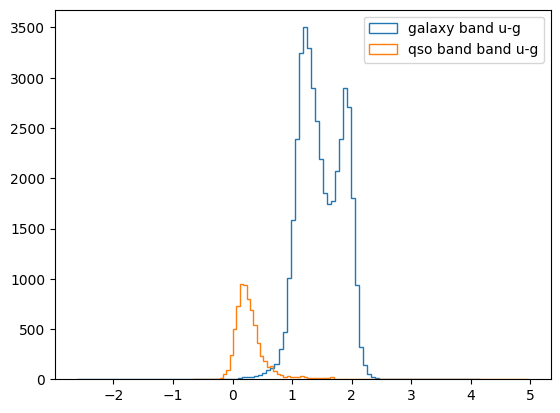

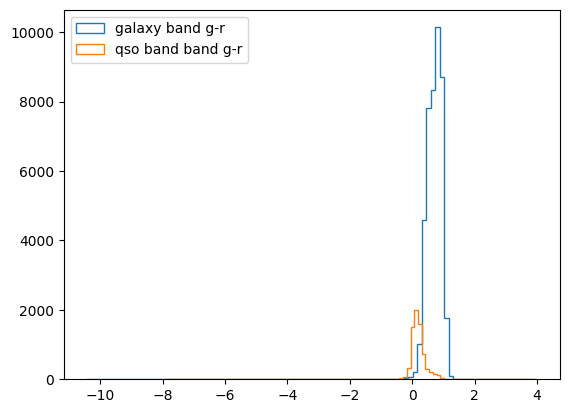

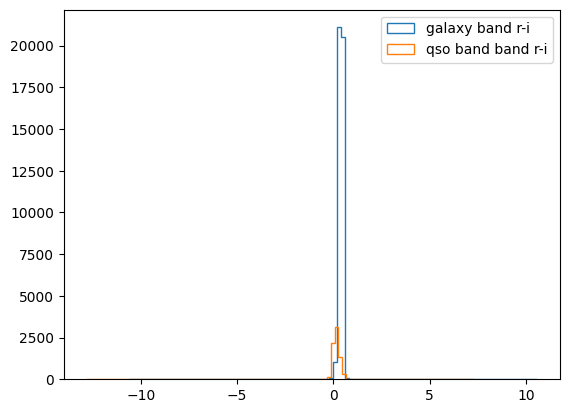

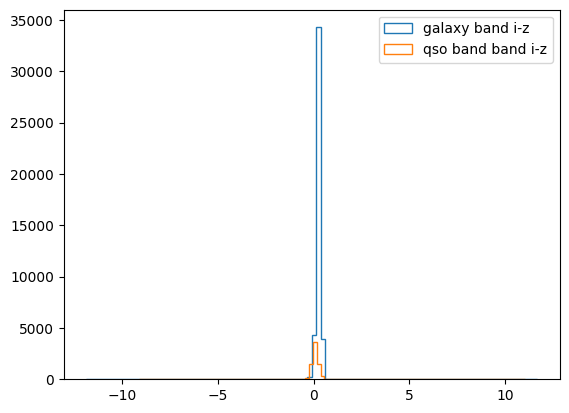

In [6]:
band = [ug, gr, ri, iz]
name = ['u-g', 'g-r', 'r-i', 'i-z']
for i in range(len(band)):
    plt.hist(band[i][classif == 0], bins = 100,histtype='step', label = f'galaxy band {name[i]}')
    plt.hist(band[i][classif ==1], bins = 100, histtype='step', label = f'qso band band {name[i]}')
    plt.legend()

    plt.show()

In [7]:
x = np.array([ug, gr, ri, iz]).T
y =classif
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

## Multilayer perceptron 

In [8]:
# Multi layer perceptron
mlp = MLPClassifier()

# Cross validation:
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (5,10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
}

# Grid search cross-validation
cv = GridSearchCV(mlp, param_grid, cv=5, n_jobs = -1)
cv.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001],
                         'hidden_layer_sizes': [(5,), (10,), (5, 10)]})

In [9]:
print(cv.best_params_)
print(cv.best_score_)

{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (5, 10)}
0.9853714285714286


In [10]:
mlp_best = cv.best_estimator_
mlp_best.fit(x_train, y_train)
y_pred = mlp_best.predict(x_test)
y_prob = mlp_best.predict_proba(x_test)[:,1]

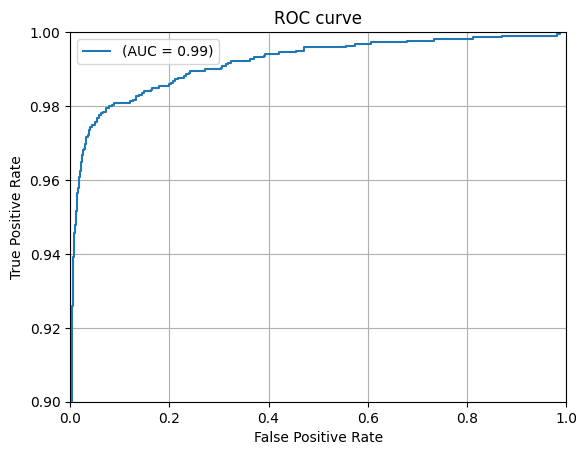

In [11]:
#ROC Curve and accuracy:
fpr, tpr, thresh = roc_curve(y_test, y_prob)  

roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'(AUC = {roc_auc:.2f})')
plt.xlim([0, 1])
plt.ylim([0.9, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid(True)
plt.legend()
plt.show()

In [12]:
C = confusion_matrix(y_pred, y_test)
print(C)
comp_test = recall_score(y_test, y_pred)
cont_test = 1 - precision_score(y_test, y_pred)
print(f'Completeness and contamination on the test set: {comp_test}, {cont_test}')
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100}%')

[[12727   136]
 [   85  2052]]
Completeness and contamination on the test set: 0.9378427787934186, 0.039775386055217576
Accuracy: 98.52666666666666%


The MLP predict precisely the quasars in the dataset with an accuracy of 
- $ Accuracy = 98.43\%$

Similar to the one obtained with GMM and KNN

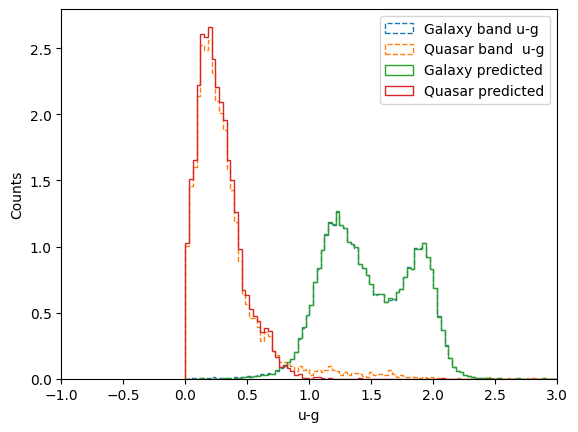

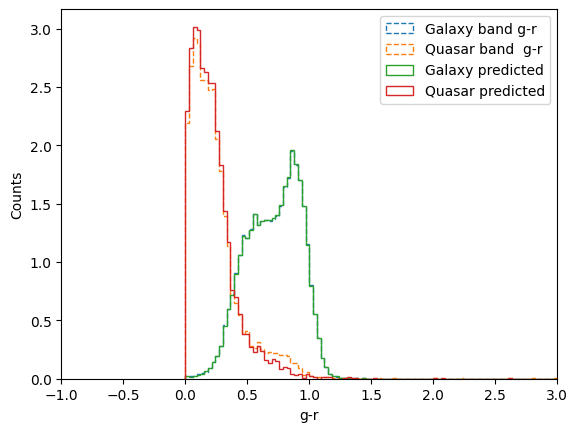

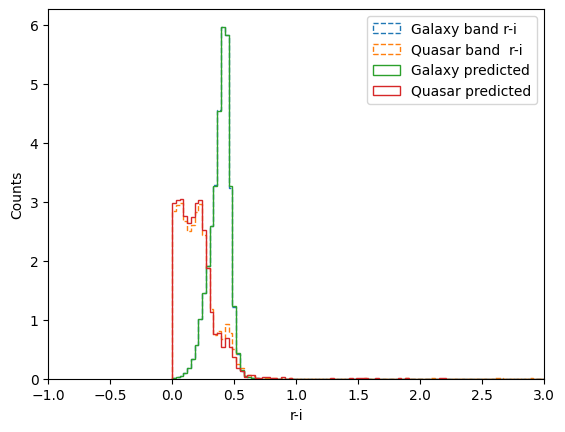

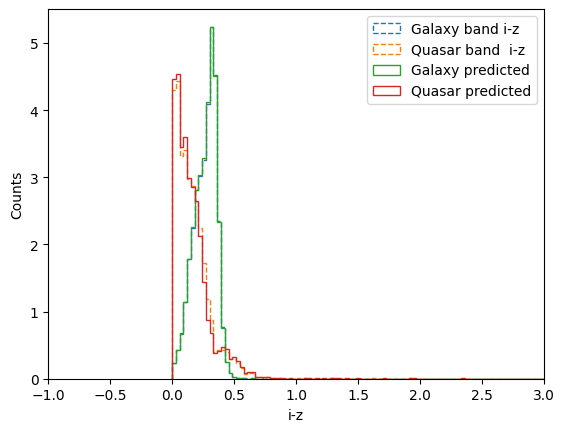

In [13]:
#Plot of predicted quasars and galaxies distribuition superimposed to the original distribuition
y_pred_tot = mlp_best.predict(x)
bins=np.linspace(0,3,100) 
for i in range(len(band)):
    plt.hist(x[classif == 0][:,i], bins = bins,histtype='step', density = True, label = f'Galaxy band {name[i]}', ls = 'dashed')
    plt.hist(x[classif ==1][:,i], bins = bins, histtype='step', density = True, label = f'Quasar band  {name[i]}', ls = 'dashed')
    plt.hist(x[y_pred_tot == 0][:,i],  bins = bins,histtype='step', density = True, label = 'Galaxy predicted')
    plt.hist(x[y_pred_tot ==1][:,i], bins = bins, histtype='step', density = True, label = 'Quasar predicted')
    plt.legend()
    plt.xlim(-1, 3)
    plt.xlabel(f'{name[i]}')
    plt.ylabel("Counts")
 
    plt.show()

## Neural network with Keras
Let's see if we can achieve similar results using keras

In [14]:
import tensorflow as tf

from tensorflow import keras
keras.backend.clear_session() 
np.random.seed(42) 
tf.random.set_seed(42)

In [15]:
from tensorboard.plugins.hparams import api as hp

# Defining the hyperparameters that we want to explore in the cross validaton
"""
HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([5, 8, (5,5),(5,10)])) 
HP_ACTIVATION = hp.HParam('activation', hp.Discrete(['relu', 'tanh'])) 
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'SGD'])) 
HP_L_RATE = hp.HParam('learning_rate', hp.RealInterval(1e-4, 1e-2)) 
"""
num_neurons = [5, 8, (5, 5), (5, 10)] #number of neurons in my hidden layer
activation_func = ['relu', 'tanh'] #activation function of my neuronss
optimizer_func = ['adam', 'SGD'] #updates the weights and biases during the learning process
lrate_values = [1e-4, 5e-4, 1e-3, 1e-2] 
METRIC_ACCURACY = 'accuracy'

In [16]:
#Cross validation and predictions
err_train = []
err_validation = []
def train_test_model(hparams, x, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) #Mantain the same proportionality of the classes in the partitions
    accuracies = []
   
    for train_index, test_index in skf.split(x, y):
        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = keras.Sequential()
        model.add(keras.layers.InputLayer(shape=(x.shape[1],))) #input layer, X.shape will be 4 in our case

        units = hparams['num_units'] #check if there are tuple in number of neurons, if so add an additional hidden layer
        if isinstance(units, tuple):
            for u in units:
                model.add(keras.layers.Dense(u, activation=hparams['activation']))
        else:
            model.add(keras.layers.Dense(units, activation=hparams['activation']))

        model.add(keras.layers.Dense(1, activation='sigmoid'))

        #optimization
        if hparams['optimizer'] == 'adam':
            optimizer = keras.optimizers.Adam(learning_rate=hparams['learning_rate'])
        else:
            optimizer = keras.optimizers.SGD(learning_rate=hparams['learning_rate'])

        model.compile(optimizer=optimizer,
                      loss='binary_crossentropy', 
                      metrics=['accuracy']) #loss function for binary classification

        model.fit(x_train, y_train, epochs=10, verbose=0)
        y_prob = model.predict(x_test)
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
       
    return np.median(accuracies)


In [17]:
#Exploring the various hyperparameters
best_score = 0 

for neurons, activation, optimizer, lrate in product(num_neurons, activation_func, optimizer_func, lrate_values):
    
    hparams = {
    'num_units': neurons,
    'activation': activation,
    'optimizer': optimizer,
    'learning_rate': lrate
    }


    score = train_test_model(hparams, x, y)
  
    if score > best_score:
        best_score = score
        best_hparams = hparams

print("Best score:", best_score)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━

In [19]:
print("Best hyperparameters:", best_hparams)


Best hyperparameters: {'num_units': (5, 5), 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.01}


In [20]:
#Saving final model with the best hyper parameters
def train_final_model(hparams, x, y):
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=(x.shape[1],)))

    units = hparams['num_units']
    if isinstance(units, tuple):
        for u in units:
            model.add(keras.layers.Dense(u, activation=hparams['activation']))
    else:
        model.add(keras.layers.Dense(units, activation=hparams['activation']))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    if hparams['optimizer'] == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hparams['learning_rate'])
    else:
        optimizer = keras.optimizers.SGD(learning_rate=hparams['learning_rate'])

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    
    return model

Let's see the performances of the best model

In [21]:
print(best_hparams)
model = train_final_model(best_hparams, x, y)
model.fit(x_train, y_train, epochs=10, verbose=0)
y_scores = model.predict(x_test).flatten()
y_pred_tot = (y_scores > 0.5).astype(int)
# Metrics
C = confusion_matrix(y_test, y_pred_tot)
tn, fp, fn, tp = C.ravel()

completeness = tp / (tp + fn)
contamination = fp / (tp + fp)


print(f"Completeness (Recall): {completeness:.2f}")
print(f"Contamination: {contamination:.2f}")

{'num_units': (5, 5), 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.01}
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Completeness (Recall): 0.94
Contamination: 0.04


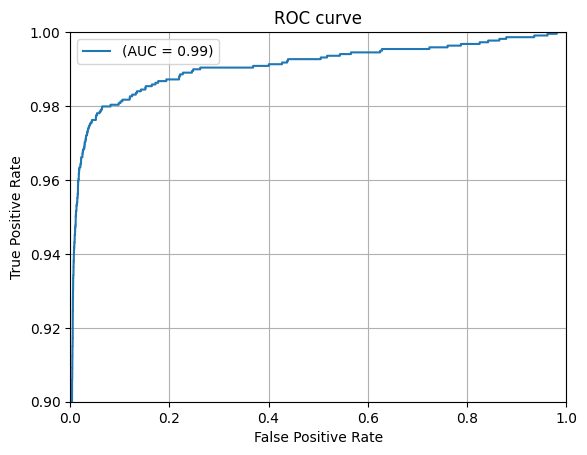

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_scores)  

roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'(AUC = {roc_auc:.2f})')
plt.xlim([0, 1])
plt.ylim([0.9, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid(True)
plt.legend()
plt.show()

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


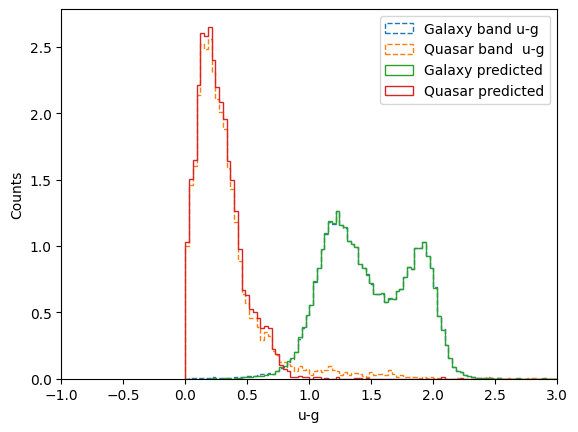

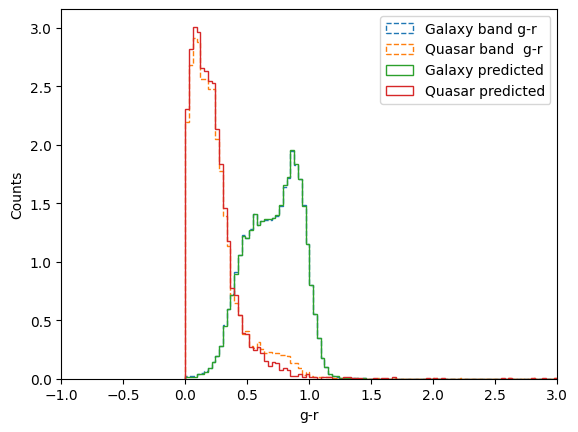

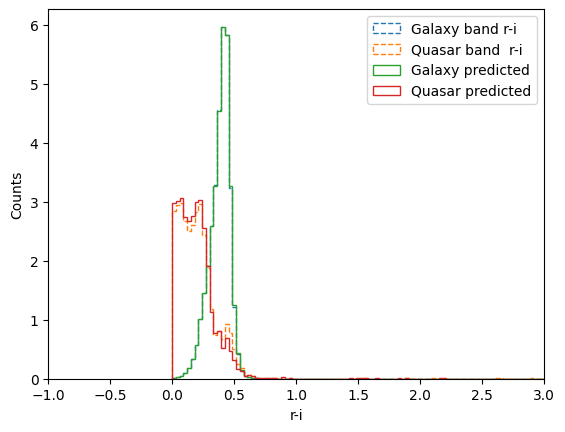

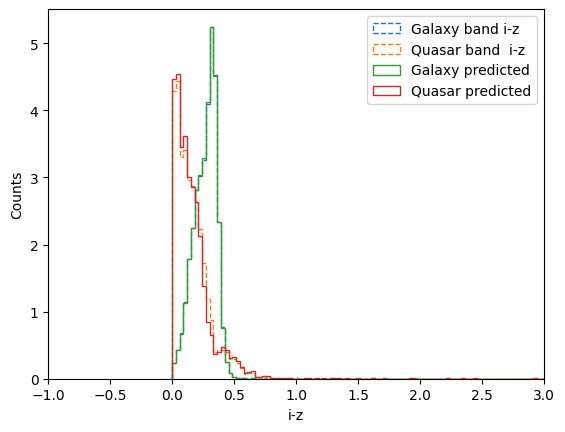

In [23]:
y_scores= model.predict(x).flatten()
y_pred_tot = (y_scores > 0.5).astype(int)
bins=np.linspace(0,3,100) 
for i in range(len(band)):
    plt.hist(x[classif == 0][:,i], bins = bins,histtype='step', density = True, label = f'Galaxy band {name[i]}', ls = 'dashed')
    plt.hist(x[classif ==1][:,i], bins = bins, histtype='step', density = True, label = f'Quasar band  {name[i]}', ls = 'dashed')
    plt.hist(x[y_pred_tot == 0][:,i],  bins = bins,histtype='step', density = True, label = 'Galaxy predicted')
    plt.hist(x[y_pred_tot ==1][:,i], bins = bins, histtype='step', density = True, label = 'Quasar predicted')
    plt.legend()
    plt.xlim(-1, 3)
    plt.xlabel(f'{name[i]}')
    plt.ylabel("Counts")
 
    plt.show()

Our neural network built with Keras predict precisely the quasars in the dataset with an accuracy of:
- $ Accuracy = 98.51\%$

